# Features — Scanpaths Damián

Replica el cálculo de features de `3-creacion-features.ipynb` usando:
- **Mapas**: `hybrid_metadata/Results/maps/HSUBANOTT/`
- **Scanpaths**: `hybrid_metadata/human_scanpaths/`
- **Output**: `Features_Damian/`

**Diferencia de coordenadas**: Los X/Y de los scanpaths de Damián están en espacio de **pantalla** (0–1920 × 0–1080), no de imagen (0–1280 × 0–1024). Para proyectar al mapa de saliencia/similitud se resta el offset `(xim, yim)` antes de escalar.

In [2]:
import os, sys, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

sys.path.insert(0, '..')

MAPS_DIR      = Path('../hybrid_metadata/Results/maps/HSUBANOTT')
SCANPATHS_DIR = Path('../hybrid_metadata/human_scanpaths')
FEATURES_PATH = '../Features_Damian'

# Rutas de mapas estáticos (mismos que notebook 3)
SALIENCY_DIR  = Path('../Results/saliency_maps/HSUBANOTT/deepgaze')
SIMILITUD_DIR = Path('../Results/target_similarity_maps/HSUBANOTT/Ivsnresnext')

GRID_SHAPE  = (24, 32)
IMAGE_W, IMAGE_H   = 1280, 1024
SCREEN_W, SCREEN_H = 1920, 1080
XIM = (SCREEN_W - IMAGE_W) / 2   # 320 px — offset horizontal pantalla→imagen
YIM = (SCREEN_H - IMAGE_H) / 2   # 28 px  — offset vertical

os.makedirs(FEATURES_PATH, exist_ok=True)

# Lista de sujetos: los que tienen mapas Y scanpath
sujetos = sorted([
    p.name for p in MAPS_DIR.iterdir()
    if p.is_dir() and (SCANPATHS_DIR / f'{p.name}_scanpaths.json').exists()
])
print(f'Sujetos a procesar: {len(sujetos)}')
print(sujetos)

Sujetos a procesar: 45
['117969', '123082', '159640', '179678', '200877', '244108', '244389', '248301', '286470', '305138', '370500', '373490', '389622', '400297', '419760', '501896', '533569', '573661', '576470', '601753', '619958', '629959', '664304', '677251', '712871', '719396', '848643', '862513', '963607', 'S101', 'S102', 'S103', 'S105', 'S106', 'S107', 'S108', 'S109', 'S111', 'S113', 'S114', 'S115', 'S116', 'S117', 'S118', 'S119']


In [3]:
# ── Funciones de carga adaptadas a hybrid_metadata ──────────────────────────

def listar_imagenes(subject_id):
    return sorted([p.stem + '.jpg' for p in (MAPS_DIR / subject_id).glob('*.npz')])


def cargar_mapas(subject_id, image_name):
    npz = np.load(MAPS_DIR / subject_id / (Path(image_name).stem + '.npz'), allow_pickle=True)
    data = {k: npz[k] for k in npz.files}
    if 'expected_ig_map' not in data: data['expected_ig_map'] = None
    if 'entropy' in data and 'entropy_map' not in data:
        data['entropy_scalar'] = data.pop('entropy')
        data['entropy_map'] = None
    data['memory_set']   = list(data['memory_set'])
    data['target_stim']  = str(data['target_stim'])
    data['target_found'] = bool(data['target_found'])
    return data


def cargar_mapa_saliencia(image_name, como_grilla=False):
    img = Image.open(SALIENCY_DIR / image_name).convert('L')
    if como_grilla:
        img = img.resize((GRID_SHAPE[1], GRID_SHAPE[0]), Image.LANCZOS)
    return np.array(img, dtype=np.float32) / 255.0


def cargar_mapa_similitud(image_name, target_name, como_grilla=False):
    fname = f'{Path(image_name).stem}_{Path(target_name).stem}.png'
    img = Image.open(SIMILITUD_DIR / fname).convert('L')
    if como_grilla:
        img = img.resize((GRID_SHAPE[1], GRID_SHAPE[0]), Image.LANCZOS)
    return np.array(img, dtype=np.float32) / 255.0


def mapa_similitud_existe(image_name, target_name):
    fname = f'{Path(image_name).stem}_{Path(target_name).stem}.png'
    return (SIMILITUD_DIR / fname).exists()


def cargar_o_crear_json(path, defaults):
    if os.path.exists(path):
        with open(path) as f: return json.load(f)
    return defaults


def screen_to_map(x_scr, y_scr, map_shape):
    """Convierte coordenadas de pantalla (1920×1080) a índices del mapa estático."""
    x_img = x_scr - XIM
    y_img = y_scr - YIM
    x_m = min(max(int(x_img * map_shape[1] / IMAGE_W), 0), map_shape[1] - 1)
    y_m = min(max(int(y_img * map_shape[0] / IMAGE_H), 0), map_shape[0] - 1)
    return x_m, y_m


def entropia_escalar(data):
    if data.get('entropy_map') is not None:
        return data['entropy_map'].sum(axis=(1, 2))
    return data.get('entropy_scalar', np.array([]))


def valor_en_fijacion(mapa, data):
    ys, xs = data['fixations_y'], data['fixations_x']
    if mapa.ndim == 2: return mapa[ys, xs]
    return mapa[np.arange(len(ys)), ys, xs]


def kl_divergencia_consecutiva(data):
    post = data['posterior']
    eps  = 1e-12
    return np.sum(post[1:] * np.log((post[1:] + eps) / (post[:-1] + eps)), axis=(1, 2))

print('Helpers cargados.')

Helpers cargados.


## 1. Información Bottom-Up (Saliencia)

In [31]:
for sujeto in sujetos:
    imagenes = listar_imagenes(sujeto)
    sp_path  = SCANPATHS_DIR / f'{sujeto}_scanpaths.json'
    with open(sp_path) as f: scanpaths = json.load(f)
    print(f'{sujeto}: {len(imagenes)} imágenes')

    for imagen in imagenes:
        if imagen not in scanpaths: continue
        mapa_sal  = cargar_mapa_saliencia(imagen, como_grilla=False)
        mapas     = cargar_mapas(sujeto, imagen)
        scanpath  = scanpaths[imagen]

        imagen_stem = imagen.replace('.jpg', '')
        output_dir  = f'{FEATURES_PATH}/{imagen_stem}/{sujeto}'
        os.makedirs(output_dir, exist_ok=True)
        json_path   = f'{output_dir}/features.json'

        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'],
            'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'], 'fijaciones': [],
        })
        data['fijaciones'] = []

        for i, (grid_y, grid_x, x_scr, y_scr) in enumerate(zip(
                mapas['fixations_y'], mapas['fixations_x'],
                scanpath['X'], scanpath['Y'])):

            x_m, y_m = screen_to_map(x_scr, y_scr, mapa_sal.shape)
            y_ini = int(grid_y) * 32
            x_ini = int(grid_x) * 32
            bloque = mapa_sal[y_ini:min(y_ini+32, mapa_sal.shape[0]),
                              x_ini:min(x_ini+32, mapa_sal.shape[1])]

            data['fijaciones'].append({
                'fixation': i, 'fix_y': int(grid_y), 'fix_x': int(grid_x),
                'saliencia_media':   float(np.mean(bloque))   if bloque.size > 0 else 0.0,
                'saliencia_mediana': float(np.median(bloque)) if bloque.size > 0 else 0.0,
                'saliencia_pixel':   float(mapa_sal[y_m, x_m]),
            })

        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

117969: 100 imágenes
123082: 102 imágenes
159640: 99 imágenes
179678: 101 imágenes
200877: 101 imágenes
244108: 99 imágenes
244389: 100 imágenes
248301: 101 imágenes
286470: 99 imágenes
305138: 102 imágenes
370500: 101 imágenes
373490: 101 imágenes
389622: 99 imágenes
400297: 101 imágenes
419760: 102 imágenes
501896: 102 imágenes
533569: 102 imágenes
573661: 99 imágenes
576470: 101 imágenes
601753: 100 imágenes
619958: 100 imágenes
629959: 101 imágenes
664304: 99 imágenes
677251: 102 imágenes
712871: 100 imágenes
719396: 86 imágenes
848643: 101 imágenes
862513: 102 imágenes
963607: 101 imágenes
S101: 101 imágenes
S102: 101 imágenes
S103: 98 imágenes
S105: 101 imágenes
S106: 102 imágenes
S107: 102 imágenes
S108: 90 imágenes
S109: 101 imágenes
S111: 100 imágenes
S113: 98 imágenes
S114: 101 imágenes
S115: 100 imágenes
S116: 101 imágenes
S117: 102 imágenes
S118: 101 imágenes
S119: 98 imágenes


## 2. Target Similarity

In [32]:
for sujeto in sujetos:
    imagenes = listar_imagenes(sujeto)
    sp_path  = SCANPATHS_DIR / f'{sujeto}_scanpaths.json'
    with open(sp_path) as f: scanpaths = json.load(f)

    for imagen in imagenes:
        if imagen not in scanpaths: continue
        mapas  = cargar_mapas(sujeto, imagen)
        target = mapas['target_stim']
        if not mapa_similitud_existe(imagen, target): continue

        mapa_sim = cargar_mapa_similitud(imagen, target, como_grilla=False)
        scanpath = scanpaths[imagen]

        imagen_stem = imagen.replace('.jpg', '')
        json_path   = f'{FEATURES_PATH}/{imagen_stem}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)

        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': target, 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })

        for i, (y, x, x_scr, y_scr) in enumerate(zip(
                mapas['fixations_y'], mapas['fixations_x'],
                scanpath['X'], scanpath['Y'])):

            x_m, y_m = screen_to_map(x_scr, y_scr, mapa_sim.shape)
            y_ini = int(y) * 32; x_ini = int(x) * 32
            bloque = mapa_sim[y_ini:min(y_ini+32, mapa_sim.shape[0]),
                              x_ini:min(x_ini+32, mapa_sim.shape[1])]

            data['fijaciones'][i].update({
                'similitud_media':   float(np.mean(bloque)),
                'similitud_mediana': float(np.median(bloque)),
                'similitud_pixel':   float(mapa_sim[y_m, x_m]),
            })

        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 3. Evidencia Visual

In [33]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas     = cargar_mapas(sujeto, imagen)
        ve_at_fix = valor_en_fijacion(mapas['visual_evidence'], mapas)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            data['fijaciones'][i].update({'evidencia_visual': float(ve_at_fix[i])})
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 4. Competencia Foveal-Periférica

In [34]:
from Model.visualsearch.visibility_map import VisibilityMap
from Model.visualsearch.grid import Grid

image_size = (768, 1024)
grid = Grid(np.array(image_size), cell_size=32)
sigma = [[4000, 0], [0, 2600]]
vis = VisibilityMap(image_size, grid, sigma, fovea_exponent=2, peripheral_exponent=1)

for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas     = cargar_mapas(sujeto, imagen)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i, (gy, gx) in enumerate(zip(mapas['fixations_y'], mapas['fixations_x'])):
            W_t = mapas['visual_evidence'][i]
            d2  = vis.at_fixation_fovea((gy, gx))
            dp  = vis.at_fixation((gy, gx))
            comp_map = np.maximum(W_t * d2, W_t * dp)
            data['fijaciones'][i].update({
                'competencia_fp_var':   float(np.var(comp_map)),
                'competencia_fp_media': float(np.mean(comp_map)),
                'competencia_fp_max':   float(np.max(comp_map)),
            })
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 5. Probabilidad Posterior

In [35]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas     = cargar_mapas(sujeto, imagen)
        post_fix  = valor_en_fijacion(mapas['posterior'], mapas)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            data['fijaciones'][i].update({'posterior': float(post_fix[i])})
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 6. Entropía del Prior

In [36]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas    = cargar_mapas(sujeto, imagen)
        mapa_sal = cargar_mapa_saliencia(imagen, como_grilla=True)
        prior_sal = mapa_sal / mapa_sal.sum()
        ent_a = float(-np.sum(prior_sal * np.log(prior_sal + 1e-12)))
        prior_mod = mapas['posterior'][0]; prior_mod = prior_mod / prior_mod.sum()
        ent_b = float(-np.sum(prior_mod * np.log(prior_mod + 1e-12)))
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            data['fijaciones'][i].update({
                'entropia_prior_saliencia': ent_a,
                'entropia_prior_modelo':    ent_b,
            })
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

/var/folders/8f/d2fjq2v97mj17hpklrr_c6yw0000gn/T/ipykernel_35122/1364548726.py:23: DeprecationWarning: LANCZOS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((GRID_SHAPE[1], GRID_SHAPE[0]), Image.LANCZOS)


## 7. Entropía del Posterior

In [37]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas    = cargar_mapas(sujeto, imagen)
        ent_post = entropia_escalar(mapas)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            data['fijaciones'][i].update({'entropia_posterior': float(ent_post[i])})
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 8. Ganancia de Información (KL)

In [38]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas    = cargar_mapas(sujeto, imagen)
        kl       = kl_divergencia_consecutiva(mapas)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            data['fijaciones'][i].update({'ganancia_informacion': float(kl[i-1]) if i > 0 else None})
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 9. Gap de Entropía con el Óptimo

In [3]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas   = cargar_mapas(sujeto, imagen)
        eig_map = mapas['expected_ig_map']
        if eig_map is None: continue
        fix_ys, fix_xs = mapas['fixations_y'], mapas['fixations_x']
        n = len(fix_ys)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(n)],
        })
        # CAMBIO: No miro mas al futuro
        #for i in range(n):
        #    optimo = float(eig_map[i].max())
        #    if i < n - 1:
        #        eig_sig = float(eig_map[i, fix_ys[i+1], fix_xs[i+1]])
        #        gap = optimo - eig_sig
        #    else:
        #        eig_sig = gap = None
        #    data['fijaciones'][i].update({
        #        'eig_optimo': optimo, 'eig_en_fijacion': eig_sig, 'gap_entropia': gap
        #    })

        # CAMBIO: Miro al pasado
        for i in range(n):
            if i > 0:
                optimo   = float(eig_map[i-1].max())
                eig_sig  = float(eig_map[i-1, fix_ys[i], fix_xs[i]])
                gap      = optimo - eig_sig
            else:
                optimo = eig_sig = gap = None
            data['fijaciones'][i].update({
                'eig_optimo': optimo, 'eig_en_fijacion': eig_sig, 'gap_entropia': gap
            })

        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 10. Distancia con la Decisión del Modelo

In [4]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas   = cargar_mapas(sujeto, imagen)
        eig_map = mapas['expected_ig_map']
        if eig_map is None: continue
        fix_ys, fix_xs = mapas['fixations_y'], mapas['fixations_x']
        n = len(fix_ys)
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(n)],
        })
        # CAMBIO: Miro al pasado — eig_map[i-1] predijo donde fijar, fix[i] es donde fijó el sujeto
        for i in range(n):
            if i > 0:
                ym, xm = np.unravel_index(eig_map[i-1].argmax(), eig_map[i-1].shape)
                dg = float(np.sqrt((fix_ys[i]-ym)**2 + (fix_xs[i]-xm)**2))
                dp = dg * 32
            else:
                ym = xm = dg = dp = None
            data['fijaciones'][i].update({
                'modelo_fix_y': int(ym) if ym is not None else None,
                'modelo_fix_x': int(xm) if xm is not None else None,
                'distancia_grilla': dg, 'distancia_pixels': dp,
            })
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 11. Competencia en Matriz de Entropías (Ratio)

In [41]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas   = cargar_mapas(sujeto, imagen)
        eig_map = mapas['expected_ig_map']
        if eig_map is None: continue
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            vals = np.sort(eig_map[i].flatten())[::-1]
            mayor, seg = float(vals[0]), float(vals[1])
            data['fijaciones'][i].update({
                'competencia_ratio_mayor': mayor,
                'competencia_ratio_segundo_mayor': seg,
                'competencia_ratio': float(seg / mayor) if mayor > 0 else None,
            })
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

## 12. Competencia en Matriz de Entropías (Densidad)

In [42]:
for sujeto in sujetos:
    for imagen in listar_imagenes(sujeto):
        mapas   = cargar_mapas(sujeto, imagen)
        eig_map = mapas['expected_ig_map']
        if eig_map is None: continue
        json_path = f'{FEATURES_PATH}/{imagen.replace(".jpg","")}/{sujeto}/features.json'
        os.makedirs(os.path.dirname(json_path), exist_ok=True)
        data = cargar_o_crear_json(json_path, defaults={
            'imagen': imagen, 'sujeto': sujeto,
            'target_stim': mapas['target_stim'], 'target_found': mapas['target_found'],
            'memory_set': mapas['memory_set'],
            'fijaciones': [{} for _ in range(len(mapas['fixations_y']))],
        })
        for i in range(len(mapas['fixations_y'])):
            mayor = float(eig_map[i].max())
            dens  = int(np.sum(eig_map[i] >= mayor * 0.95))
            data['fijaciones'][i].update({
                'competencia_densidad':      dens,
                'competencia_densidad_norm': float(dens / eig_map[i].size),
            })
        with open(json_path, 'w') as f: json.dump(data, f, indent=2)

---
## Comparación de distribuciones: Features_Damian vs Features

Compara las distribuciones de cada feature entre los sujetos comunes a ambos datasets.

In [5]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

def cargar_features(features_path):
    rows = []
    for img_dir in sorted(Path(features_path).iterdir()):
        if not img_dir.is_dir(): continue
        imagen = img_dir.name + '.jpg'
        for subj_dir in sorted(img_dir.iterdir()):
            jp = subj_dir / 'features.json'
            if not jp.exists(): continue
            with open(jp) as f: data = json.load(f)
            for fij in data['fijaciones']:
                rows.append({'imagen': imagen, 'sujeto': subj_dir.name,
                             'target_found': data['target_found'],
                             'mss': len(data['memory_set']), **fij})
    df = pd.DataFrame(rows)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='ignore')
    return df

df_dam  = cargar_features('../Features_Damian')
df_orig = cargar_features('Features')

# hybrid_metadata usa IDs como '117969'; HSEM usa 'et_117969' → normalizar quitando 'et_'
hsem_norm_map = {s.replace('et_', ''): s for s in df_orig['sujeto'].unique()}
common_norm   = set(df_dam['sujeto'].unique()) & set(hsem_norm_map.keys())

dam_ids  = common_norm
orig_ids = {hsem_norm_map[n] for n in common_norm}

df_dam  = df_dam[df_dam['sujeto'].isin(dam_ids)]
df_orig = df_orig[df_orig['sujeto'].isin(orig_ids)]

print(f'Sujetos en común        : {len(common_norm)}')
print(f'Fijaciones Features_Damian : {len(df_dam):,}')
print(f'Fijaciones Features        : {len(df_orig):,}')


/var/folders/8f/d2fjq2v97mj17hpklrr_c6yw0000gn/T/ipykernel_94997/3494438264.py:19: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


Sujetos en común        : 39
Fijaciones Features_Damian : 54,735
Fijaciones Features        : 38,188


In [6]:
META_COLS = ['imagen','sujeto','target_found','mss','fixation','fix_y','fix_x','modelo_fix_y','modelo_fix_x']
FEAT_COLS = [c for c in df_dam.columns if c not in META_COLS and c in df_orig.columns and pd.api.types.is_numeric_dtype(df_dam[c])]

print(f"{'Feature':<40s}  {'Media_Dam':>10}  {'Media_Orig':>10}  {'Diff%':>7}  {'KS p-val':>10}")
print('-' * 85)
for feat in FEAT_COLS:
    a = df_dam[feat].dropna()
    b = df_orig[feat].dropna()
    if len(a) == 0 or len(b) == 0: continue
    diff_pct = 100 * (a.mean() - b.mean()) / (abs(b.mean()) + 1e-12)
    ks_stat, ks_p = ks_2samp(a.sample(min(len(a), 5000), random_state=42),
                              b.sample(min(len(b), 5000), random_state=42))
    sig = ' ***' if ks_p < 0.001 else (' **' if ks_p < 0.01 else (' *' if ks_p < 0.05 else ''))
    print(f'{feat:<40s}  {a.mean():>10.4f}  {b.mean():>10.4f}  {diff_pct:>6.1f}%  {ks_p:>10.4f}{sig}')
print('\n* p<0.05  ** p<0.01  *** p<0.001  (test KS)')

Feature                                    Media_Dam  Media_Orig    Diff%    KS p-val
-------------------------------------------------------------------------------------
saliencia_media                               0.1054      0.1095    -3.7%      0.1857
saliencia_mediana                             0.1012      0.1053    -3.8%      0.1627
saliencia_pixel                               0.0453      0.1165   -61.1%      0.0000 ***
similitud_media                               0.0928      0.0778    19.2%      0.0000 ***
similitud_mediana                             0.0852      0.0717    18.8%      0.0000 ***
similitud_pixel                               0.0335      0.0820   -59.2%      0.0000 ***
evidencia_visual                             -3.3265     -3.9060    14.8%      0.0000 ***
competencia_fp_var                            4.5941      4.5700     0.5%      0.7279
competencia_fp_media                         -0.1942     -0.2177    10.8%      0.0000 ***
competencia_fp_max            

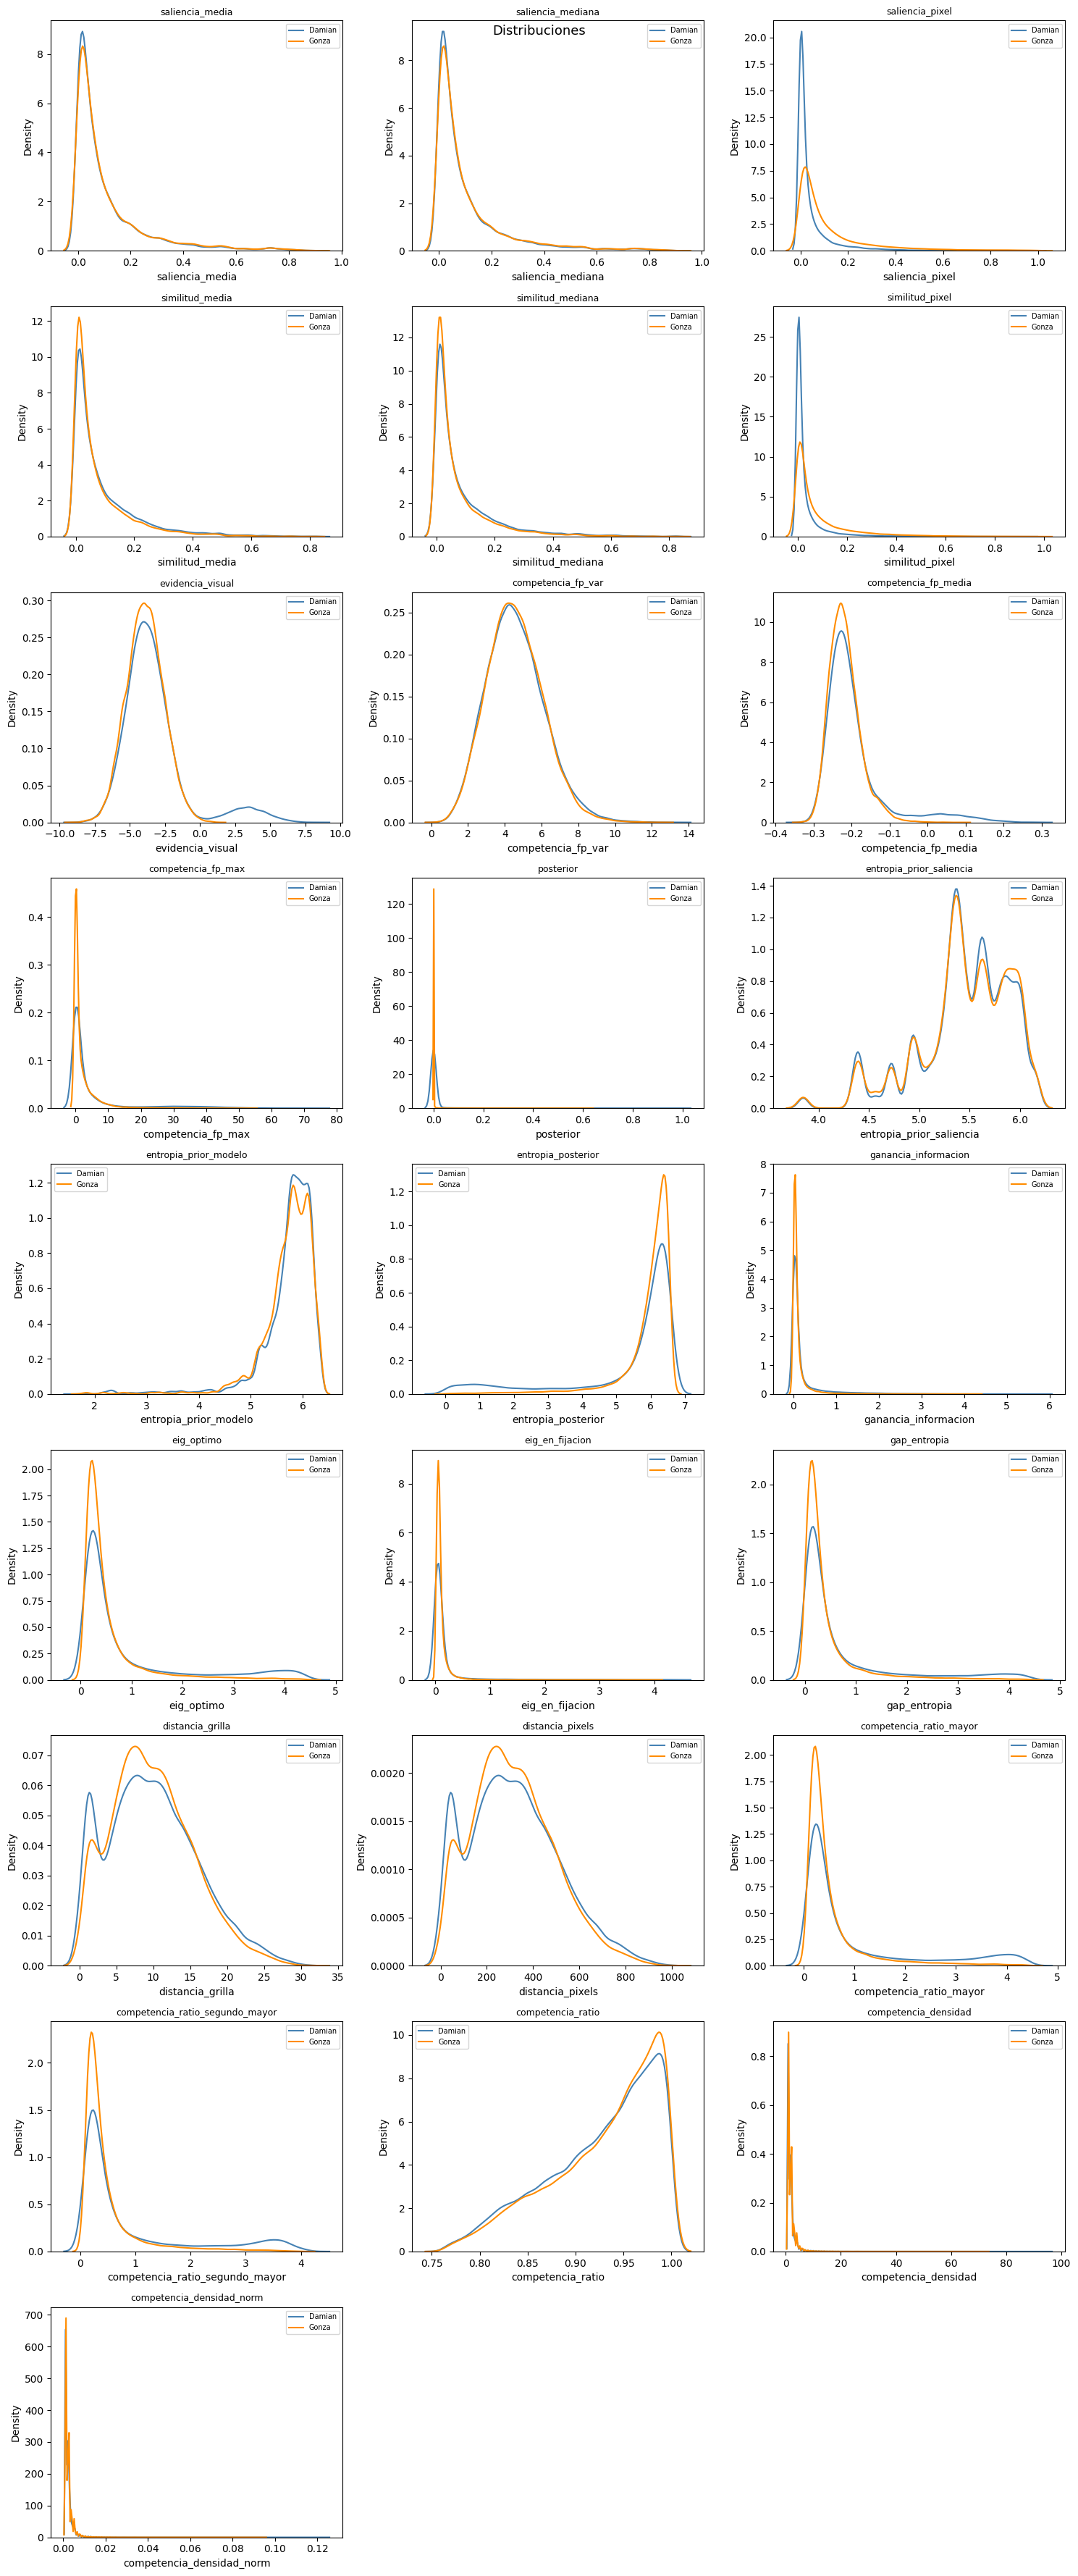

In [7]:
import seaborn as sns

n_cols = 3
n_rows = -(-len(FEAT_COLS) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
fig.suptitle('Distribuciones', fontsize=13)

for ax, feat in zip(axes.flat, FEAT_COLS):
    sns.kdeplot(df_dam[feat].dropna(), ax=ax, color='steelblue', label='Damian')
    sns.kdeplot(df_orig[feat].dropna(), ax=ax, color='darkorange', label='Gonza')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

# Ocultar ejes sobrantes
for ax in axes.flat[len(FEAT_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()